In [196]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [197]:
random.seed(1234)

fashion_df = pd.read_csv("./data/fashion_data.csv")
fashion_df["Order Date"] = pd.to_datetime(fashion_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
fashion_df.set_index("Order Date", inplace=True)
fashion_df.drop(columns=["Unnamed: 0"], inplace=True)

fashion_df = fashion_df.fillna(0)

fashion_df.head()

,Shipping Address State,Revenue,Survey ResponseID,weather_category,ratio_cold_weather,ratio_fashion_accessories,ratio_hot_weather,ratio_indoor_basic,ratio_other,ratio_rain_protection,ppt,tmax,tmin,tavg
Order Date,,,,,,,,,,,,,,
2017-01-01,AL,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,25.626,13.849,4.712,9.280
2017-01-01,AR,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.999,10.667,4.430,7.548
2017-01-01,AZ,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,4.824,9.969,4.154,7.061
2017-01-01,CA,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,3.760,9.559,0.137,4.848
2017-01-01,CO,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.385,2.787,-9.496,-3.354


In [198]:
# Filter for one state 
# Arrange by date 
# Calc temp - temp(t=-365)
# Calc first oder difference in revenue
# for each state filter out days which were only used to calc temp-365 / meaning the day bevore revenue was recorded

In [199]:
df_one_state_filter = fashion_df["Shipping Address State"] == "CA"
df_one_state = fashion_df[df_one_state_filter].copy()

### Create 365 day laged temperature column

In [200]:
df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(3)

### Create 365 laged rain column

In [201]:
df_one_state["Rain_No_Season"] = df_one_state["ppt"] - df_one_state["ppt"].shift(365)
df_one_state["Rain_No_Season"] = df_one_state["Rain_No_Season"].round(3)

### Create first order diff for Revenue

In [202]:
first_order_diff = [0]

for j in range(1,len(df_one_state)): 
    first_order_diff.append(df_one_state["Revenue"][j] - df_one_state["Revenue"][j-1])

df_one_state["first_order_diff_Revenue"] = first_order_diff
df_one_state["first_order_diff_Revenue"] = df_one_state["first_order_diff_Revenue"].round(4)

### Lag first order diff for Revenue by 1 day

From testing with the autocorrelation we know that lagging the first order diff of revenue by 1 day is the best fit for our data    

In [203]:
df_one_state.loc[:, "first_order_diff_Revenue_lagged"] = df_one_state["first_order_diff_Revenue"].shift(-1)

### Remove days wich were only used for temp calculations

In [204]:
df_one_state = df_one_state.iloc[365:, :]

#### Linear regression for: First order difference Revenue ~ 365 lag Temp + 1 day lag first order difference Revenue

In [205]:
df_one_state.loc[:, 'Time'] = np.arange(len(df_one_state))

### Testing some Visualization

When comparing the Temperature change vs Previous Year against the 7 day laged first order difference from Revenue we can see that changes in the weather (positive and negative), result in a tick in revenue. Note: This observation is purley visual

In [210]:
"""df_one_state_plot = df_one_state.copy()
df_one_state_plot["first_order_diff_Revenue"] = df_one_state_plot["first_order_diff_Revenue"].shift(7)

df_one_state_plot = df_one_state.loc['2019-01-01':'2019-12-31']
df_one_state_plot = df_one_state_plot.reset_index()
# Plotting
fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)


ax1.plot(df_one_state_plot["Order Date"],
            df_one_state_plot["Temp_No_Season"],
            color="tab:red")

# Second line

ax2 = ax1.twinx()
ax2.plot(df_one_state_plot["Order Date"],
         df_one_state_plot["first_order_diff_Revenue"],
         color="tab:blue")


# Decorations
# ax1 (left Y axis)
ax1.set_xlabel('Time', fontsize=20)
ax1.tick_params(axis='x', rotation=0, labelsize=12)
ax1.set_ylabel('Temperature change vs Previous Year', color='tab:red', fontsize=20)
ax1.tick_params(axis='y', rotation=0, labelcolor='tab:red' )
ax1.grid(alpha=.4)

# ax2 (right Y axis)
ax2.set_ylabel("First order difference in Revenue", color='tab:blue', fontsize=20)
ax2.tick_params(axis='y', labelcolor='tab:blue')
fig.tight_layout()
plt.show()

plt.show()"""

'df_one_state_plot = df_one_state.copy()\ndf_one_state_plot["first_order_diff_Revenue"] = df_one_state_plot["first_order_diff_Revenue"].shift(7)\n\ndf_one_state_plot = df_one_state.loc[\'2019-01-01\':\'2019-12-31\']\ndf_one_state_plot = df_one_state_plot.reset_index()\n# Plotting\nfig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)\n\n\nax1.plot(df_one_state_plot["Order Date"],\n            df_one_state_plot["Temp_No_Season"],\n            color="tab:red")\n\n# Second line\n\nax2 = ax1.twinx()\nax2.plot(df_one_state_plot["Order Date"],\n         df_one_state_plot["first_order_diff_Revenue"],\n         color="tab:blue")\n\n\n# Decorations\n# ax1 (left Y axis)\nax1.set_xlabel(\'Time\', fontsize=20)\nax1.tick_params(axis=\'x\', rotation=0, labelsize=12)\nax1.set_ylabel(\'Temperature change vs Previous Year\', color=\'tab:red\', fontsize=20)\nax1.tick_params(axis=\'y\', rotation=0, labelcolor=\'tab:red\' )\nax1.grid(alpha=.4)\n\n# ax2 (right Y axis)\nax2.set_ylabel("First order difference

## Linear Regression

In [208]:

import statsmodels.api as sm
df_one_state = df_one_state.fillna(0)

x = df_one_state[["Time", "Temp_No_Season", "Rain_No_Season", "first_order_diff_Revenue_lagged"]]
y = df_one_state['Revenue']
model = sm.OLS(y, sm.add_constant(x))
results = model.fit()
#print(results.params)
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.488
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     453.3
Date:                Sun, 02 Feb 2025   Prob (F-statistic):          1.68e-274
Time:                        18:02:58   Log-Likelihood:                -11621.
No. Observations:                1905   AIC:                         2.325e+04
Df Residuals:                    1900   BIC:                         2.328e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

From this model we see that nether rain nor temperature have a statiscally signifcant impact on our prediction of revenue

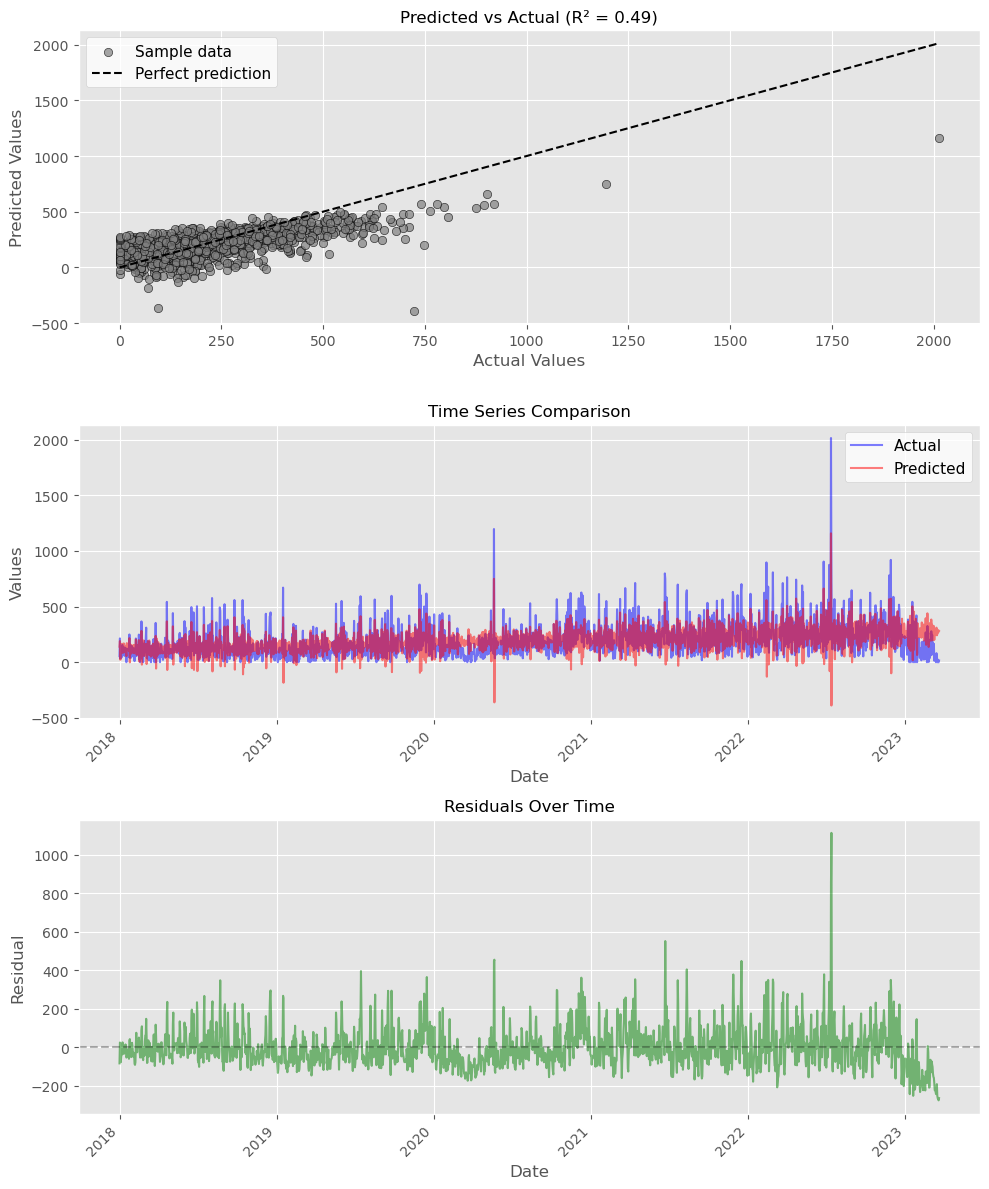

In [148]:
# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# First subplot: Predicted vs Actual (scatter)
ax1.scatter(y, y_pred, edgecolor='k', facecolor='grey', alpha=0.7, label='Sample data')
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Perfect prediction')
ax1.legend(facecolor='white', fontsize=11)
ax1.set_title(f'Predicted vs Actual (R² = {r2:.2f})', fontsize=12)
ax1.set_xlabel('Actual Values')
ax1.set_ylabel('Predicted Values')

# Second subplot: Time series comparison
dates = df_one_state.index  # Assuming your dates are in the index
ax2.plot(dates, y, 'b-', alpha=0.5, label='Actual')
ax2.plot(dates, y_pred, 'r-', alpha=0.5, label='Predicted')
ax2.legend(facecolor='white', fontsize=11)
ax2.set_title('Time Series Comparison', fontsize=12)
ax2.set_xlabel('Date')
ax2.set_ylabel('Values')

# Third subplot: Residuals over time
residuals = y - y_pred
ax3.plot(dates, residuals, 'g-', alpha=0.5)
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax3.set_title('Residuals Over Time', fontsize=12)
ax3.set_xlabel('Date')
ax3.set_ylabel('Residual')

# Rotate date labels for better readability
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

fig.tight_layout()
plt.show()

In [149]:
x = df_one_state[["Temp_No_Season"]]
y = df_one_state['Revenue']
model = sm.OLS(y, sm.add_constant(x))
results = model.fit()
#print(results.params)
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.01879
Date:                Sun, 02 Feb 2025   Prob (F-statistic):              0.891
Time:                        17:23:33   Log-Likelihood:                -12259.
No. Observations:                1905   AIC:                         2.452e+04
Df Residuals:                    1903   BIC:                         2.453e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            193.6118      3.460     55.

In [228]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_one_state_plot = df_one_state.copy()
df_one_state_plot = df_one_state_plot.reset_index()
#df_one_state_plot["first_order_diff_Revenue"] = df_one_state_plot["first_order_diff_Revenue"].shift(7)


# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add temperature line
fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["tavg"],
        name="Averrage Temp",
        line=dict(color="red")
    ),
    secondary_y=False
)

# Add revenue line
fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["ratio_hot_weather"].rolling(30).mean().round(2),
        name="SMA30 Ratio hot weather",
        line=dict(color="blue")
    ),
    secondary_y=True
)

# Update layout
fig.update_layout(
    title="Temperature and Revenue Change Over Time",
    xaxis_title="Order Date",
    width=1200,
    height=600
)

# Update y-axes labels
#fig.update_yaxes(title_text="Temperature", secondary_y=False)
#fig.update_yaxes(title_text="Revenue Change", secondary_y=True)

# Show the plot
fig.show()

# Linear Regression with sub categories

### Calc first order diff of Hot weather clothing sales

In [246]:
df_one_state["Hot_weather_revenue"] = (df_one_state["Revenue"] * df_one_state["ratio_hot_weather"]).round(3)

In [247]:
first_order_diff = [0]

for j in range(1,len(df_one_state)): 
    first_order_diff.append(df_one_state["Hot_weather_revenue"][j] - df_one_state["Hot_weather_revenue"][j-1])

df_one_state["first_order_diff_hot_weather_revenue"] = first_order_diff
df_one_state["first_order_diff_hot_weather_revenue"] = df_one_state["first_order_diff_hot_weather_revenue"].round(4)

In [253]:

df_one_state = df_one_state.fillna(0)

SMA_temp_no_season = df_one_state["Temp_No_Season"].rolling(30).mean().round(2)
SMA_temp_no_season = SMA_temp_no_season.fillna(0)

x = SMA_temp_no_season #df_one_state[["Temp_No_Season", "first_order_diff_Revenue", "tavg"]]
y = df_one_state["first_order_diff_hot_weather_revenue"]
#y = SMA_ratio_hot_weather
model = sm.OLS(y, sm.add_constant(x))
results = model.fit()
#print(results.params)
print(results.summary())

                                     OLS Regression Results                                     
Dep. Variable:     first_order_diff_hot_weather_revenue   R-squared:                       0.000
Model:                                              OLS   Adj. R-squared:                 -0.001
Method:                                   Least Squares   F-statistic:                 0.0001295
Date:                                  Sun, 02 Feb 2025   Prob (F-statistic):              0.991
Time:                                          18:29:04   Log-Likelihood:                -10665.
No. Observations:                                  1905   AIC:                         2.133e+04
Df Residuals:                                      1903   BIC:                         2.135e+04
Df Model:                                             1                                         
Covariance Type:                              nonrobust                                         
                     coef    s

In [256]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_one_state_plot = df_one_state.copy()
df_one_state_plot = df_one_state_plot.reset_index()
#df_one_state_plot["first_order_diff_Revenue"] = df_one_state_plot["first_order_diff_Revenue"].shift(7)


# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add temperature line
fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["tavg"],
        name="Averrage Temp",
        line=dict(color="red")
    ),
    secondary_y=False
)

# Add revenue line
fig.add_trace(
    go.Scatter(
        x=df_one_state_plot["Order Date"],
        y=df_one_state_plot["first_order_diff_hot_weather_revenue"],
        name="first_order_diff_hot_weather_revenue",
        line=dict(color="blue")
    ),
    secondary_y=True
)

# Update layout
fig.update_layout(
    title="Temperature and Revenue Change Over Time",
    xaxis_title="Order Date",
    width=1200,
    height=600
)

# Update y-axes labels
#fig.update_yaxes(title_text="Temperature", secondary_y=False)
#fig.update_yaxes(title_text="Revenue Change", secondary_y=True)

# Show the plot
fig.show()